# 📈 Bootstrapping Zero Prices With FEDInvest Data

<br>

<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Volume-Three-Chapter-Three/blob/master/colab/Colab_Bootstrapping_Zero_Prices.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>

  <a href="https://mybinder.org/v2/gh/PatrickJHess/Volume-Three-Chapter-Three/master?urlpath=lab/tree/notebooks/Bootstrapping Zero Prices.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>

  <a href="https://patrickjhess.github.io/Volume-Three-Chapter-Three/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>
</div>

🧮 An important step in constructing the term structure utilizes coupon bonds to estimate zero prices, a process commonly known as bootstrapping zero prices or present-value factors. When done with ordinary least squares (OLS), the result is a collection of discrete zero prices: a basis for calculating spot and forward rates for specific dates. In this notebook, FEDInvest data is used to bootstrap zero prices with OLS.

💡 As we proceed, two critical considerations should be noted:

1. **🚧 First Approximation**: Bootstrapping with OLS is a first approximation of term structure estimation. Because the term structure is essential for pricing various financial instruments, discrete estimates alone are inadequate; the gaps between these points must be addressed—a challenge that is the focus of the following chapter.  
2. **📊 Data Quality**: The reliability of any estimate is fundamentally tied to the quality of the underlying data. While the FEDInvest data may not represent the current state of the art, it remains highly effective for demonstrating core concepts that are applicable throughout a professional career.

:::{important} [ ▼ ] How to use this page: Run, Copy, & Download
:class: dropdown

<ul>
  <li><b>⏻ Run code right here:</b> Click the <b>Power Button</b> icon at the top of the screen to activate <b>Live Code</b>.</li>
  <li><b>📋 Copy code:</b> Hover over any code block and click the <b>Clipboard icon</b> in the top-right corner.</li>
  <li><b>📥 Download this file:</b> Click the <b>Download icon</b> (downward arrow) at the top right of the screen to save this exact notebook to your computer.</li>
</ul>
:::

:::{important} 🤔 Notebook Setup: Why the "Try/Except" Imports?
:class: dropdown

**The Goal:**
To ensure this notebook runs perfectly whether you are using **Google Colab**, a local **Jupyter instance**, or a remote server without you having to manually install software.

* **External Libraries:** NumPy and Pandas are the "heavy hitters" for data. They aren't always installed by default.
* **The `try/except` Logic:** This is a safety net.
    1. We **try** to import the library.
    2. If it fails (because it's not installed), the **except** block triggers a `%pip install` to download it automatically.
* **Aliasing (`as np`):** We rename `numpy` to `np` to save keystrokes. In professional finance code, `np` and `pd` are the universal shorthand.
  
:::

## 🛠️ Preparing the Notebook

<details>
<summary><b>👉 Click to Expand: 📦 Importing Libraries, Modules, and Functions</b></summary>

As a best practice, we always begin by importing our necessary dependencies in the very first code cell. Notice how lightweight our imports are here: just datetime and the `pandas` and `numpy` libraries. ✨

This simplicity is a direct result of using the `financial_quant` package, which handles the heavy lifting behind the scenes. 🏗️ By keeping complicated setup details out of sight, we ensure the spotlight remains focused exactly where it belongs—on the core analysis. 🎯

```python
from datetime import datetime, date

try:
    import numpy as np
except:
    %pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    %pip -q install pandas
    import pandas as pd
```
**👀 Keep an eye out**: As we progress, pay attention to how the `financial_quant` package is imported as `fq`, and how every reference to its functions begins with fq.. 💡 This follows the exact same standard practice we demonstrated in Chapter One with NumPy (np) and Pandas (pd).

</details>


In [1]:

from datetime import datetime, date
try:
    import numpy as np
except:
    %pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    %pip -q install pandas
    import pandas as pd

## 📦 Getting Functions from financial_quant package

:::{important} 🔌 Professional Packaging: How GitHub Installations Work
:class: dropdown

**The Logic:**
Instead of copying and pasting functions or tricking Python into reading raw text from a URL, we are using Python's official package installer (`pip`). We are telling `pip` to bypass the public registry and install our custom quantitative toolkit directly from a GitHub repository, treating it exactly like standard libraries such as `pandas` or `numpy`.

**The Workflow:**
1. **Fetch & Build:** The `!pip install git+https://...` command tells your Jupyter environment to clone the repository from GitHub and install the `financial_quant` package directly into your system's `site-packages` directory.
2. **Import:** `import financial_quant as fq` loads the package into your notebook's memory and assigns it the quick alias `fq`.
3. **Routing:** Behind the scenes, a special file called `__init__.py` acts as the package's "front door." It automatically gathers complex tools from deeply nested folders (like our fixed-income models and chart visualizers) and serves them up directly to the surface.
4. **Execute:** You don't have to worry about where the files live. You just type `fq.one_y_axis()` or `fq.calc_ytm()`, and Python immediately knows where to route the request.

**Why do this?**
This is exactly how professional software engineering teams manage and distribute code. It keeps your notebooks **incredibly clean**, ensures everyone is using the exact same version of the math models, and guarantees your code is 100% portable to any cloud environment.
:::

In [2]:
%pip install -q git+https://github.com/PatrickJHess/quant_repo.git
import financial_quant as fq

Note: you may need to restart the kernel to use updated packages.


### 🗄️ Getting the Data from FEDInvest
With our custom modules in place, the next step is to retrieve the actual Treasury bond data. We begin by defining our target observation date—in this case, April 27, 2026.

By passing this target date into our custom FEDInvest function, we extract three critical pieces of information:

1. df: The raw DataFrame containing the Treasury prices, coupon rates, and maturity dates for that specific day.

2. stamp: The confirmed date the prices were recorded, serving as a vital check to ensure our data pull matches our requested date.

3. settlement: The calculated actual settlement date for these trades. As discussed earlier, knowing the exact settlement date is essential for accurately calculating accrued interest and zero prices.

Before moving on to standardizing and cleaning the dataset, we print the dates for quick verification and use df.head() to inspect the initial structure of our raw data.

In [3]:
my_date=datetime(2026, 4,27)
# Fetch Treasury data for a specific date
df, stamp,settlement = fq.FEDInvest(my_date)

#Display price and date and settlement
display(f'Date of prices {stamp}  Settlement date  {settlement}')

# Display the first few rows
df.head()

'Date of prices 2026-04-27  Settlement date  2026-04-28'

,CUSIP,SECURITY TYPE,RATE,MATURITY DATE,CALL DATE,BUY,SELL,END OF DAY
1,912797SN8,MARKET BASED BILL,0.000%,2026-04-30,NaN,0.000000,99.970000,99.980111
2,912797TL1,MARKET BASED BILL,0.000%,2026-05-05,NaN,99.920333,99.920000,99.930389
3,912797SP3,MARKET BASED BILL,0.000%,2026-05-07,NaN,99.900556,99.900278,99.910000
4,912797TR8,MARKET BASED BILL,0.000%,2026-05-12,NaN,99.850417,99.850000,99.860000
5,912797QN0,MARKET BASED BILL,0.000%,2026-05-14,NaN,99.830708,99.830472,99.840444


### 📏 Standardizing the data
Raw financial data is rarely ready for immediate analysis, and the Treasury data retrieved from FEDInvest is no exception. Before we can use this data to build our payoff matrix and bootstrap zero prices, it needs to be rigorously cleaned and standardized.

By passing our raw DataFrame (df) into the custom clean_FEDInvest function, we perform several crucial under-the-hood transformations. While the specific cleaning steps depend on the raw data's condition, this process typically involves:

* Standardizing column names and data types for seamless processing.

* Formatting maturity and coupon payment dates to align with our settlement calculations.

* Filtering out anomalies or securities that do not fit the criteria for our OLS estimation.

The result is clean_df, a polished and uniform dataset. We then create a smaller subset, demo_df, using the .head() method to quickly verify that our standardizing function executed correctly and our data is structurally ready for the next phase.

In [4]:
clean_df=fq.clean_FEDInvest(df)
demo_df=clean_df.head()
display(demo_df)

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY
MATURITY DATE,,,,,
2026-04-30,MARKET BASED BILL,0.000,0.000000,99.97000,99.980111
2026-04-30,MARKET BASED NOTE,4.875,0.000000,100.00000,100.000000
2026-04-30,MARKET BASED NOTE,0.750,0.000000,99.96875,99.968750
2026-04-30,MARKET BASED NOTE,2.375,0.000000,99.96875,100.000000
2026-05-05,MARKET BASED BILL,0.000,99.920333,99.92000,99.930389


## 🏗️ Creating the Payoff Matrix

📊 Our primary goal is to construct a DataFrame to organize payment information following the collection of bond price data for 399 securities on Apr 27, 2026. This matrix is initially populated with zeros, using rows for each of the 399 securities and columns for payment dates derived from unique maturity dates adjusted for settlement.

⚖️ To maintain full column rank within the payoff matrix when zero prices are estimated with ordinary least squares (OLS), bond inclusion is restricted to those whose payment dates match zero prices at unique maturity dates. Given that the entire FEDInvest security set is unlikely to satisfy these conditions, we rigorously verify each bond's payoff dates against the 268 unique maturity dates of the 399 bonds. The OLS parameter defaults to False, but if assigned True, the payoff matrix construction concludes with the addition of the previous eligible bond.

🧹 Once all eligible bonds are processed, the DataFrame is refined to include only those rows and columns containing non-zero values.

⏳ The `create_payoff_df` function generates this payoff DataFrame by accepting an argument such as `clean_df`. During processing, the function evaluates bond payment dates against the `all_maturities` set. Because processing hundreds of bonds is time-intensive, a completion indicator is included, reaching 100% only after all eligible securities are successfully added.

````{dropdown} 🔍 Click to see <code>create_payoff_df</code>

```python
def create_payoff_df(df, settlement,OLS=False):
    adjusted_maturities = adjust_bond_pay_dates(list(df.index))
    all_maturities = set(adjusted_maturities)

    df_payoff_columns = sorted(all_maturities)
    df_payoff_index=[i for i in range(len(df.index))]

    df_payoff = pd.DataFrame(
        np.zeros((len(df), len(df_payoff_columns))),
        columns=df_payoff_columns,
        index=df_payoff_index
    )
    total_rows = len(df)
    # Define a clean, pleasing HTML template for our status box
    def status_box(current, total):
        return f"""
        <div style="font-family: Arial, sans-serif; padding: 10px 15px; background-color: #f8f9fa;
                    border-left: 4px solid #007bff; border-radius: 4px; width: fit-content; color: #333;">
            <b style="color: #007bff;">⚙️ Processing Bonds:</b> {current} of {total} added to DataFrame
        </div>
        """
    
    # initial display showing 0 bonds added
    progress_ui = display(HTML(status_box(0, total_rows)), display_id=True)

    for index,(maturity, coupon) in enumerate(zip(df.index, df['Coupon'])):

        # bond_pay_data returns payment dates and amounts
        row_pay_data = bond_pay_data(maturity, coupon, settlement=settlement)

        # Find any dates that aren't already columns
        new_dates = set(row_pay_data[0].flatten()) - all_maturities

        if new_dates:
          if OLS:
            df_clean = df_payoff.loc[(df_payoff != 0).any(axis=1),
                                         (df_payoff != 0).any(axis=0)]
            print("✅ DataFrame Complete (Exited Early)!")
            return df_clean
          else:
            # ✅ FIX: Add new dates to our master set and reindex
            all_maturities.update(new_dates)
            df_payoff = df_payoff.reindex(columns=sorted(all_maturities), fill_value=0.0)

        #    fill up the columns
        df_payoff.loc[index, row_pay_data[0]] = row_pay_data[1]
         # update the progress bar
        progress_ui.update(HTML(status_box(index + 1, total_rows)))
    # re-sort the columns so dates are chronological
    df_payoff = df_payoff.reindex(sorted(df_payoff.columns), axis=1)
    progress_ui.update(HTML("""
        <div style="font-family: Arial, sans-serif; padding: 10px 15px; background-color: #e6f4ea;
                    border-left: 4px solid #34a853; border-radius: 4px; width: fit-content; color: #137333;">
            <b>✅ DataFrame Complete!</b> All bonds added successfully.
            </div>
            """))
    return df_payoff
```
````
````{dropdown} ✂️ Code snippet to see an example of the function.

```python
# assumes that create_payoff_df has been imported
# and that clean_df has been created
from IPython.display import display, HTML
import pandas as pd
# set OLS to True for ordinatry least squares
df_payoff_matrix=fq.create_payoff_df(clean_df[:10],settlement,OLS=True)
display(df_payoff_matrix)
```
````


## 🏗️ Creating a DataFrame for OLS from FEDInvest (April 27<sup>th</sup>, 2026)
🔢 Constructing the df_payoff_matrix should yield a full-rank matrix. We can confirm this using numpy.linalg.matrix_rank. Because the module accepts DataFrames directly, there is no need to convert the DataFrame to a NumPy array first.

In [5]:
# The completion index assumes all eligible bonds are processed
df_payoff_matrix = fq.create_payoff_df(clean_df, settlement, OLS=True)

# A full rank matrix is required to infer zero prices
# We use the NumPy linalg module to confirm the rank
rank = np.linalg.matrix_rank(df_payoff_matrix)
num_columns = df_payoff_matrix.shape[1]

# Evaluate and display the rank and shape of the DataFrame
if rank < num_columns:
    text = '⚠️ Payoff matrix is not full rank'
else:
    text = '✅ Payoff matrix is full rank'

display(f'{text} | Rank is {rank} | Shape is {df_payoff_matrix.shape}')

✅ DataFrame Complete (Exited Early)!


'✅ Payoff matrix is full rank | Rank is 193 | Shape is (302, 193)'

### 🔍 A Few Observations About the Results
🎯 For approximately 75% of the bonds (302 out of 399), all payment dates successfully mapped to a maturity date, resulting in 193 unique payment dates (the columns of our DataFrame).

📊 We will utilize this cash flow matrix, combined with the bonds' transaction (dirty) prices, to determine the least-squares zero prices.

➕ Before estimating these zero prices, we must first calculate the dirty prices by adding the accrued interest to the quoted (clean) prices.



:::::{admonition} ✍️ Application: Create a DataFrame of payoff data OLS with June 1<sup>st</sup> 2023 data from FEDInvest site and calculate the rank.


**The Challenge**:Using the functions `FEDInvest`, `Clean_FEDInvest`, and `create_payoff_df`


*Recall:*
1. The pricing date (sole argument of FEDInvest) must be datetime object (either `'date` or `datetime`.
2. FEDInvest returns a DataFrame, the pricing and settlement dates.
3. The lialg module of NumPy has a function `rank`

**Goal**: Test your ability to use the functions and determine the rank of the payoff matrix

---
    
::::{dropdown} 🛟 Need hints or a solution?

:::{dropdown} 💡 Hints

* **Imports:** If you are using a different notebook, import libraries and modules.
* **Create the pricing date:** 'date(year,month,day)`
* **Use functions:** `FEDInvest`, `Clean_FEDInvest`, `create_payoff_df`, NumPy `rank`
  


:::

:::{dropdown} ✅ Example Of Solution
## Example of Code


```py
# price datetime
from datetime import datetime
import numpy as np
price_date=date(2023,6,1)

# get the data with FEDInvest (returns pricing and settlement as well DataFrame)
df_app,pricing_date,settlement=fq.FEDInvest(price_date)

# standardize the DataFrame
clean_df_app=fq.clean_FEDInvest(df_app)

# calculate the payoff matrix DataFrame
df_payoff_matrix_app=fq.create_payoff_df(clean_df_app,settlment,OLS=True)

# calculate and number of columns of DataFrame
rank=np.linalg.matrix_rank(df_payoff_matrix_app)
num_columns=df_payoff_matrix_app.shape[1]

# show rank and shape of DataFrame
if rank<num_columns:
 text='Payoff matrix is not full rank'
else:
 text='Payoff matrix is full rank'
display(f'{text}, Ranks is {rank}, Shape is {df_payoff_matrix_app.shape} ')

```
:::
::::
:::::

## 💵 Calculating Transaction (Dirty) Prices
📖 As discussed in Chapter Two of this volume, the data retrieved from FEDInvest occasionally returns a zero for bid, ask, or end-of-day prices. Consistent with the previous chapter, we calculate the clean price using either the mean of the bid and ask prices, or the highest value among the three price columns (Price Bid, Price Ask, and END OF DAY).

⚙️ In the following cell, we first create the DataFrame df_302 from the first 302 rows of clean_df (the bonds included in df_payoff_matrix). Both the clean prices and the accrued interest are calculated (the accrued_interest function from financial_quant).

➕ Finally, the transaction (dirty) prices are calculated by simply adding the accrued interest to the quoted (clean) prices.

In [6]:
# Create the DataFrame from the bonds included in the payoff_matrix
# .copy() is used to make sure the DataFrames aren't linked
# The number of rows is the first element returned by .shape
num_rows = df_payoff_matrix.shape[0]
df_302 = clean_df[:num_rows].copy()

# Vectorized calculation of clean prices
# Find the boolean value where both bid and ask prices are valid (>0)
bid_ask_true = (df_302['Price Bid'] > 0) & (df_302['Price Ask'] > 0)

# Bid/Ask average assigned to true_value
true_value = (df_302['Price Bid'] + df_302['Price Ask']) / 2

# Maximum of the three prices assigned to false_value
false_value = df_302[['END OF DAY', 'Price Bid', 'Price Ask']].max(axis=1)

# Equivalent to a vectorized if-else assignment for an array of clean prices
df_302['Clean Price'] = np.where(bid_ask_true, true_value, false_value)

# Calculate accrued interest with the apply method
# The settlement date was previously returned by FEDInvest
df_302['Accrued Interest'] = df_302.apply(
    lambda row: fq.accrued_interest(
        maturity=row.name,        # Value of the index is the maturity date
        coupon=row['Coupon'],
        settlement=settlement
    ),
    axis=1                        # Explicitly state axis=1 for row-by-row execution
)

# Vectorize the dirty price calculation
df_302['Dirty Price'] = df_302['Clean Price'] + df_302['Accrued Interest']

display(df_302)

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY,Clean Price,Accrued Interest,Dirty Price
MATURITY DATE,,,,,,,,
2026-04-30,MARKET BASED BILL,0.000,0.000000,99.97000,99.980111,99.980111,0.000000,99.980111
2026-04-30,MARKET BASED NOTE,4.875,0.000000,100.00000,100.000000,100.000000,2.410566,102.410566
2026-04-30,MARKET BASED NOTE,0.750,0.000000,99.96875,99.968750,99.968750,0.370856,100.339606
2026-04-30,MARKET BASED NOTE,2.375,0.000000,99.96875,100.000000,100.000000,1.174378,101.174378
2026-05-05,MARKET BASED BILL,0.000,99.920333,99.92000,99.930389,99.920166,0.000000,99.920166
...,...,...,...,...,...,...,...,...
2035-05-15,MARKET BASED NOTE,4.250,99.703125,99.68750,99.656250,99.695312,1.925414,101.620727
2035-08-15,MARKET BASED NOTE,4.250,99.578125,99.56250,99.531250,99.570312,0.845304,100.415616
2035-11-15,MARKET BASED NOTE,4.000,97.500000,97.50000,97.468750,97.500000,1.812155,99.312155


## 🧮 Estimating the 193 Zero Prices
We pass the DataFrame df_payoff_matrix and the Dirty Price column of df_302 into the lstsq function. The function returns a tuple containing four elements:

🎯 Coefficients: The estimated zero prices.

* **📉 Residuals**: The sum of squared residuals, representing the squared deviations of the actual bond prices from the prices predicted by our zero prices.

* **🔢 Rank**: The effective rank of our coefficient matrix (df_payoff_matrix).

* **💡 Singular Values**: A measure of the information content for each column.

🗑️ Because we already calculated and confirmed the rank** of our matrix in a previous step, we will disregard the third output (the rank) by assigning it to the _ (placeholder) variable.

📊 After calculating the zero prices, we create the Estimated_Zeros DataFrame to store these estimates alongside their corresponding spot and forward rates. Additionally, we generate a Summary_Statistics DataFrame containing the average squared error and the minimum and maximum singular values of the columns.

In [7]:
# Least squares estimation of zero prices
# DataFrames and Pandas Series are passed directly to the function
# Note: rcond=None is used to suppress a NumPy FutureWarning.
zero_prices, sum_squared, _, singular_values = np.linalg.lstsq(
    df_payoff_matrix,
    df_302['Dirty Price'],
    rcond=None
)

# Calculation of spot and forward rates requires maturities converted to years
# The columns of df_payoff_matrix are payment dates
# Convert column values and settlement to Pandas datetimes and take the difference
maturity = pd.to_datetime(df_payoff_matrix.columns) - pd.to_datetime(settlement)

# Use days to calculate maturity in years
maturity_years = maturity.days / 365.25

# Calculate continuous spot rates
spot_rates = -np.log(zero_prices) / maturity_years

# Calculate continuous forward rates
forward_rates = -np.diff(np.log(zero_prices)) / np.diff(maturity_years)
# Insert NaN at index zero to align with zero prices and spot rates
forward_rates = np.insert(forward_rates, 0, np.nan)

# Create the Estimated_Zeros DataFrame
# The data dictionary
zero_data = {
    'Zero Prices': zero_prices,
    'Spot Rates': spot_rates,
    'Forward Rates': forward_rates
}

# The DataFrame (index is the payment dates)
Estimated_Zeros = pd.DataFrame(zero_data, index=df_payoff_matrix.columns)
display(Estimated_Zeros)

# Create a Summary Statistics DataFrame
# The data dictionary
summary_lstsq = {
    'Average Sum Squared Errors': sum_squared / len(df_payoff_matrix),
    'Column Max Info': np.max(singular_values),
    'Column Min Info': np.min(singular_values)
}

# The DataFrame
Summary_Statistics = pd.DataFrame(summary_lstsq, index=['Summary Statistics']).T
display(Summary_Statistics)

,Zero Prices,Spot Rates,Forward Rates
2026-04-30,0.999764,0.043167,NaN
2026-05-05,0.999202,0.041673,0.041075
2026-05-07,0.999004,0.040434,0.036100
2026-05-12,0.998502,0.039109,0.036723
2026-05-14,0.998306,0.038706,0.035886
...,...,...,...
2035-02-15,0.686582,0.042720,0.049390
2035-05-15,0.678263,0.042917,0.050025
2035-08-15,0.669844,0.043098,0.049588
2035-11-15,0.661820,0.043223,0.047845


,Summary Statistics
Average Sum Squared Errors,0.000907
Column Max Info,202.553654
Column Min Info,98.588422


##📊 Summarizing the Results and Graphing Spot Rates
The estimated spot rates hover around 4%. The April 30, 2026 estimate is slightly higher, though it is worth noting that the four securities maturing on that date lack ask prices. Forward rates reflect future short-term spot rates and exhibit greater volatility than actual spot rates. The average sum of squares implies a standard deviation of less than three cents—a comfortably small figure given the assumed par values of one hundred. Furthermore, the ratio of the maximum and minimum column information is consistent with estimates that are not unduly influenced by outliers or data errors.

📈 The function one_y_axis is used to graph the estimated spot rates. The resulting graph highlights two important observations:

* **🔍 General Pattern**: Although all spot rates are close to 4%, they decline in the short term but increase with longer maturities.

* **📉 Density of Estimates**: The frequency of estimates declines as maturity increases. There are many "dead zones" (data gaps) as we move further out on the timeline.

🌉 The second point highlights a critical limitation of discrete estimates. In order to use these estimates to price other securities or forecast future values, we must extrapolate between the existing data points. This exercise requires making mathematical assumptions about the relationship between adjacent estimates—a challenge that the next chapter of this volume will tackle directly.

❓ Do you want to save the file? (y/n) (press enter for n):  y


### ***⌛ Generating A Path***

### ✅ **File Path Generated:**
`/home/pat/Basic_Concepts_Fixed_Income/Term_Structure/Chapter_Three/notebooks/output`

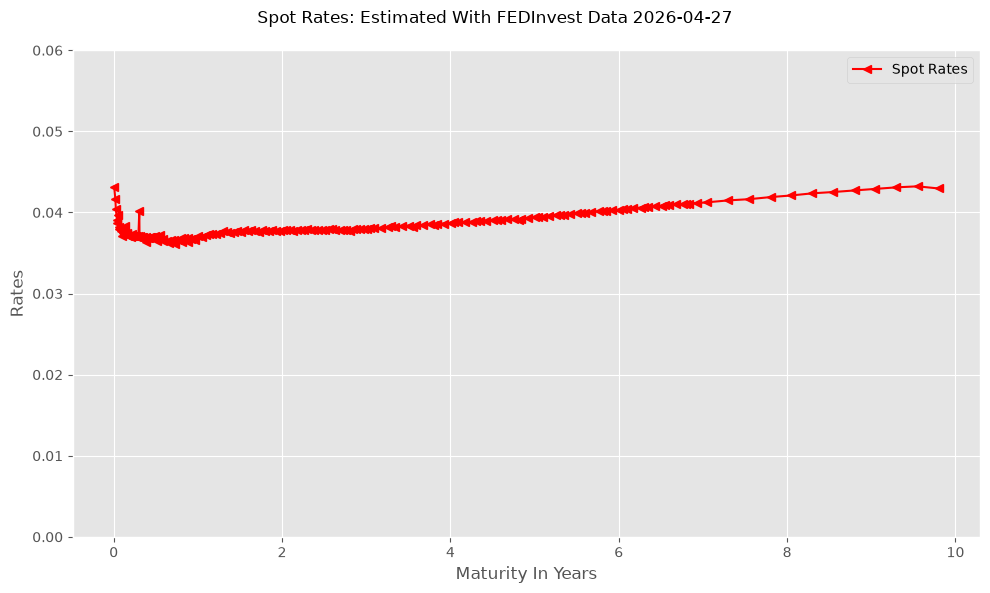

In [8]:
settlement=date(2025,4,27)

# Initialize a dictionary to hold plot-saving configurations.
save_config={}


# Initialize a dictionary to hold plot-saving configurations.
save_config={}
string_date='04/27/2026'

# Set the x-axis and y-axis data for the plot.
xaxis=maturity_years            #Maturity relative to 1/21/2025
data=[Estimated_Zeros['Spot Rates']]       #y-axis data

# Define the file name and folder for the saved plot.


# Attempt to extract the plot title from the file name.
try:
    title = save_config['File Name'][:-4]
#'File' key not found or string is too short), set a default title.
except:
    title = 'Spot Rates: Estimated With FEDInvest Data '+my_date.strftime('%Y-%m-%d')

# Define labels for the data series, y-axis, and x-axis.
series=['Spot Rates']
ylabel='Rates'
xlabel='Maturity In Years'

# Set plot aesthetics: marker styles, y-axis limits, figure size, and color.
markers=['<']
ylim=[0.0,0.06]
size=(10,6)
# Define colors as red
colors=['r']

# Call the plotting function with all the prepared data and configurations
fq.one_y_axis(xaxis, data, title, series, xlabel, ylabel, markers, size, ylim,
           save_config=save_config,colors=colors)

:::{dropdown} ✨ AI Study Assistant
:open:

Select a prompt below to open Google AI and explore these concepts further. *(Sign in to save your chat history!)*

---

✨ [**Why use least squares to estimate zero prices? ↗**](https://www.google.com/search?udm=50&q=Why+use+least+squares+to+estimate+zero+prices?)

---

✨ [**Is it necessary to interpolate between least square estimates of zero prices? ↗**](https://www.google.com/search?udm=50&q=Is+it+necessary+to+interpolate+between+least+square+estimates+of+zero+prices?)

---

✨ [**Does it make sense to estimate zero prices with corporate bonds? ↗**](https://www.google.com/search?udm=50&q=Does+it+make+sense+to+estimate+zero+prices+with+corporate+bonds?)


:::